In [1]:
"""
Numerical Analysis of Grid Search Results.

This script performs comprehensive statistical and ML analysis to discover
relationships between:
- Target variables: test_accuracy, final_empirical_compression
- Predictors: beta, bottleneck_width (optionally: model_arch)

Methods used:
- Statistical analysis (correlations, regressions, ANOVA)
- Supervised learning (Random Forest, Gradient Boosting for feature importance)
- Unsupervised learning (clustering, PCA for pattern discovery)

Note: Run with `uv run notebooks/numerical_analisys.py`
      Plots are saved to reports/numerical_analysis/ without blocking.
"""

import json
import os
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')

# Fixed colormap
BOTTLENECK_CMAP = 'viridis'

In [2]:
def get_notebook_dir():
	"""Get the directory containing the current notebook or script."""
	try:
		# Works in .py files
		return Path(__file__).parent.resolve()
	except NameError:
		return Path(os.getcwd()).resolve()

In [3]:
# Load data
PROJECT_ROOT = get_notebook_dir().parent
RESULTS_PATH = PROJECT_ROOT / 'results' / 'efficientnet' / 'grid_search_results_final.json'
OUTPUT_DIR = PROJECT_ROOT / 'reports' / 'efficientnet' / 'numerical_analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Loading data from: {RESULTS_PATH}')

with open(RESULTS_PATH, 'r', encoding='utf-8') as f:
	raw_data = json.load(f)

df = pd.DataFrame(raw_data)
print(f'Loaded {len(df)} experiments')
print(f'\nColumns: {list(df.columns)}')
print(f'\nData types:\n{df.dtypes}')

Loading data from: C:\Users\Michael\Documents\projects\DDIB-Toolkit\results\efficientnet\grid_search_results_final.json
Loaded 793 experiments

Columns: ['model_arch', 'bottleneck_width', 'beta', 'seed', 'test_accuracy', 'final_train_loss', 'final_val_loss', 'final_train_acc', 'final_val_acc', 'final_empirical_compression', 'final_train_empirical_compression', 'final_effective_capacity_utilization', 'final_train_effective_capacity_utilization']

Data types:
model_arch                                        str
bottleneck_width                                int64
beta                                          float64
seed                                            int64
test_accuracy                                 float64
final_train_loss                              float64
final_val_loss                                float64
final_train_acc                               float64
final_val_acc                                 float64
final_empirical_compression                   float6

In [4]:
# =============================================================================
# SECTION 1: BASIC STATISTICAL ANALYSIS
# =============================================================================
print('\n' + '=' * 60)
print('SECTION 1: BASIC STATISTICAL ANALYSIS')
print('=' * 60)

# Descriptive statistics
print('\n--- Descriptive Statistics ---')
desc_stats = df[
	['test_accuracy', 'final_empirical_compression', 'beta', 'bottleneck_width']
].describe()
print(desc_stats)

# Correlation analysis
print('\n--- Correlation Matrix ---')
corr_cols = [
	'test_accuracy',
	'final_empirical_compression',
	'beta',
	'bottleneck_width',
	'final_val_loss',
	'final_effective_capacity_utilization',
]
corr_matrix = df[corr_cols].corr()
print(corr_matrix.round(3))


SECTION 1: BASIC STATISTICAL ANALYSIS

--- Descriptive Statistics ---
       test_accuracy  final_empirical_compression          beta  \
count     793.000000                   793.000000  7.930000e+02   
mean       59.071400                     8.342130  1.008827e+01   
std        30.298787                     0.234077  2.857222e+01   
min         9.880000                     6.827076  1.000000e-08   
25%        12.350000                     8.243001  1.000000e-06   
50%        78.950000                     8.276402  1.000000e-03   
75%        80.210000                     8.450838  1.000000e+00   
max        81.990000                     9.491118  1.000000e+02   

       bottleneck_width  
count        793.000000  
mean         509.518285  
std          662.664331  
min           16.000000  
25%           64.000000  
50%          128.000000  
75%          512.000000  
max         2048.000000  

--- Correlation Matrix ---
                                      test_accuracy  \
test_acc


Saved: correlation_matrix.png


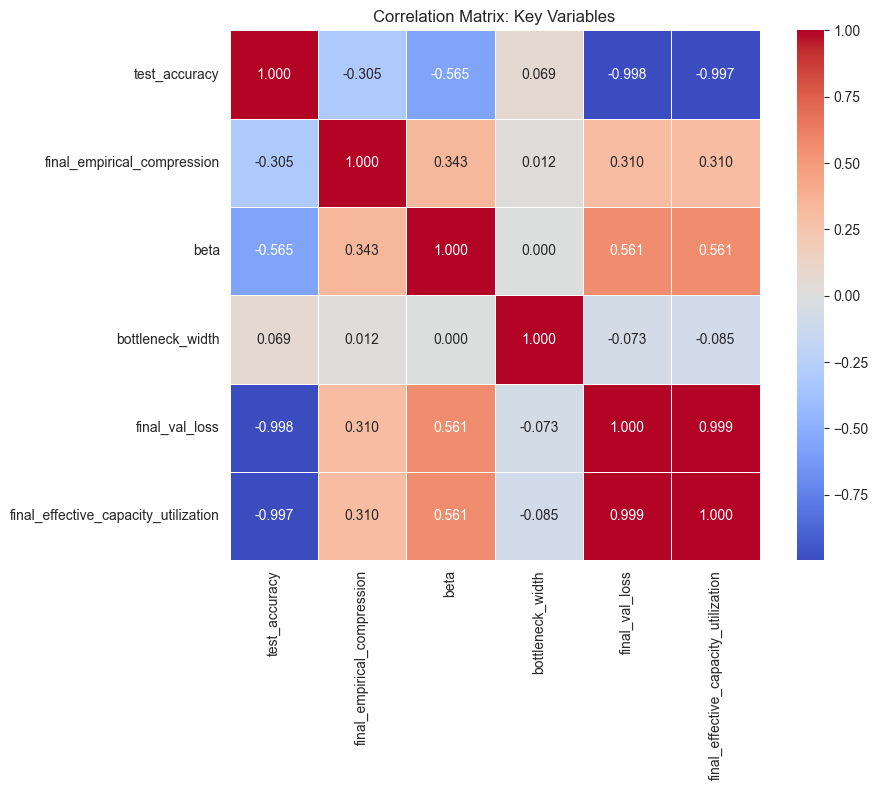

In [5]:
# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
	corr_matrix,
	annot=True,
	fmt='.3f',
	cmap='coolwarm',
	center=0,
	ax=ax,
	square=True,
	linewidths=0.5,
)
ax.set_title('Correlation Matrix: Key Variables')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation_matrix.png', dpi=150)
print(f'\nSaved: correlation_matrix.png')
plt.show()

In [6]:
# Analyze beta relationship with targets
print('\n--- Beta vs Test Accuracy ---')
beta_accuracy_corr = df['beta'].corr(df['test_accuracy'])
print(f'Correlation: {beta_accuracy_corr:.4f}')

# Log-transform beta for better analysis
df['log_beta'] = np.log10(df['beta'])
log_beta_accuracy_corr = df['log_beta'].corr(df['test_accuracy'])
print(f'Log-Beta vs Accuracy correlation: {log_beta_accuracy_corr:.4f}')


--- Beta vs Test Accuracy ---
Correlation: -0.5654
Log-Beta vs Accuracy correlation: -0.8111


In [7]:
# Analyze bottleneck_width relationship with targets
print('\n--- Bottleneck Width vs Test Accuracy ---')
width_accuracy_corr = df['bottleneck_width'].corr(df['test_accuracy'])
print(f'Correlation: {width_accuracy_corr:.4f}')

# Check for non-linear relationship
df['log_width'] = np.log2(df['bottleneck_width'])
log_width_accuracy_corr = df['log_width'].corr(df['test_accuracy'])
print(f'Log2-Width vs Accuracy correlation: {log_width_accuracy_corr:.4f}')


--- Bottleneck Width vs Test Accuracy ---
Correlation: 0.0692
Log2-Width vs Accuracy correlation: 0.1087


In [8]:
# =============================================================================
# SECTION 2: LINEAR REGRESSION ANALYSIS
# =============================================================================
print('\n' + '=' * 60)
print('SECTION 2: LINEAR REGRESSION ANALYSIS')
print('=' * 60)

# Prepare features
X = df[['log_beta', 'bottleneck_width']].copy()
y_accuracy = df['test_accuracy']
y_compression = df['final_empirical_compression']

# Model 1: Predict test_accuracy
print('\n--- Model 1: Predicting Test Accuracy ---')
lr_accuracy = LinearRegression()
lr_accuracy.fit(X, y_accuracy)
y_pred_acc = lr_accuracy.predict(X)

print(f'R2 Score: {r2_score(y_accuracy, y_pred_acc):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_accuracy, y_pred_acc)):.4f}')
print(f'\nCoefficients:')
print(f'  log_beta: {lr_accuracy.coef_[0]:.4f}')
print(f'  bottleneck_width: {lr_accuracy.coef_[1]:.4f}')
print(f'  Intercept: {lr_accuracy.intercept_:.4f}')

# Cross-validation
cv_scores = cross_val_score(lr_accuracy, X, y_accuracy, cv=5, scoring='r2')
print(f'\nCross-validation R2: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})')


SECTION 2: LINEAR REGRESSION ANALYSIS

--- Model 1: Predicting Test Accuracy ---
R2 Score: 0.6628
RMSE: 17.5826

Coefficients:
  log_beta: -7.7601
  bottleneck_width: 0.0032
  Intercept: 34.1086

Cross-validation R2: 0.6564 (+/- 0.0502)


In [9]:
# Model 2: Predict final_empirical_compression
print('\n--- Model 2: Predicting Empirical Compression ---')
lr_compression = LinearRegression()
lr_compression.fit(X, y_compression)
y_pred_comp = lr_compression.predict(X)

print(f'R2 Score: {r2_score(y_compression, y_pred_comp):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_compression, y_pred_comp)):.4f}')
print(f'\nCoefficients:')
print(f'  log_beta: {lr_compression.coef_[0]:.4f}')
print(f'  bottleneck_width: {lr_compression.coef_[1]:.4f}')
print(f'  Intercept: {lr_compression.intercept_:.4f}')

cv_scores_comp = cross_val_score(lr_compression, X, y_compression, cv=5, scoring='r2')
print(f'\nCross-validation R2: {cv_scores_comp.mean():.4f} (+/- {cv_scores_comp.std() * 2:.4f})')


--- Model 2: Predicting Empirical Compression ---
R2 Score: 0.0830
RMSE: 0.2240

Coefficients:
  log_beta: 0.0213
  bottleneck_width: 0.0000
  Intercept: 8.4040

Cross-validation R2: 0.0776 (+/- 0.0885)


In [10]:
# Ridge regression for regularization
print('\n--- Ridge Regression (Regularized) ---')
ridge_accuracy = Ridge(alpha=1.0)
ridge_accuracy.fit(X, y_accuracy)
print(f'Ridge R2: {r2_score(y_accuracy, ridge_accuracy.predict(X)):.4f}')
print(
	f'Ridge Coefficients: log_beta={ridge_accuracy.coef_[0]:.4f}, width={ridge_accuracy.coef_[1]:.4f}'
)


--- Ridge Regression (Regularized) ---
Ridge R2: 0.6628
Ridge Coefficients: log_beta=-7.7591, width=0.0032



Saved: regression_predictions.png


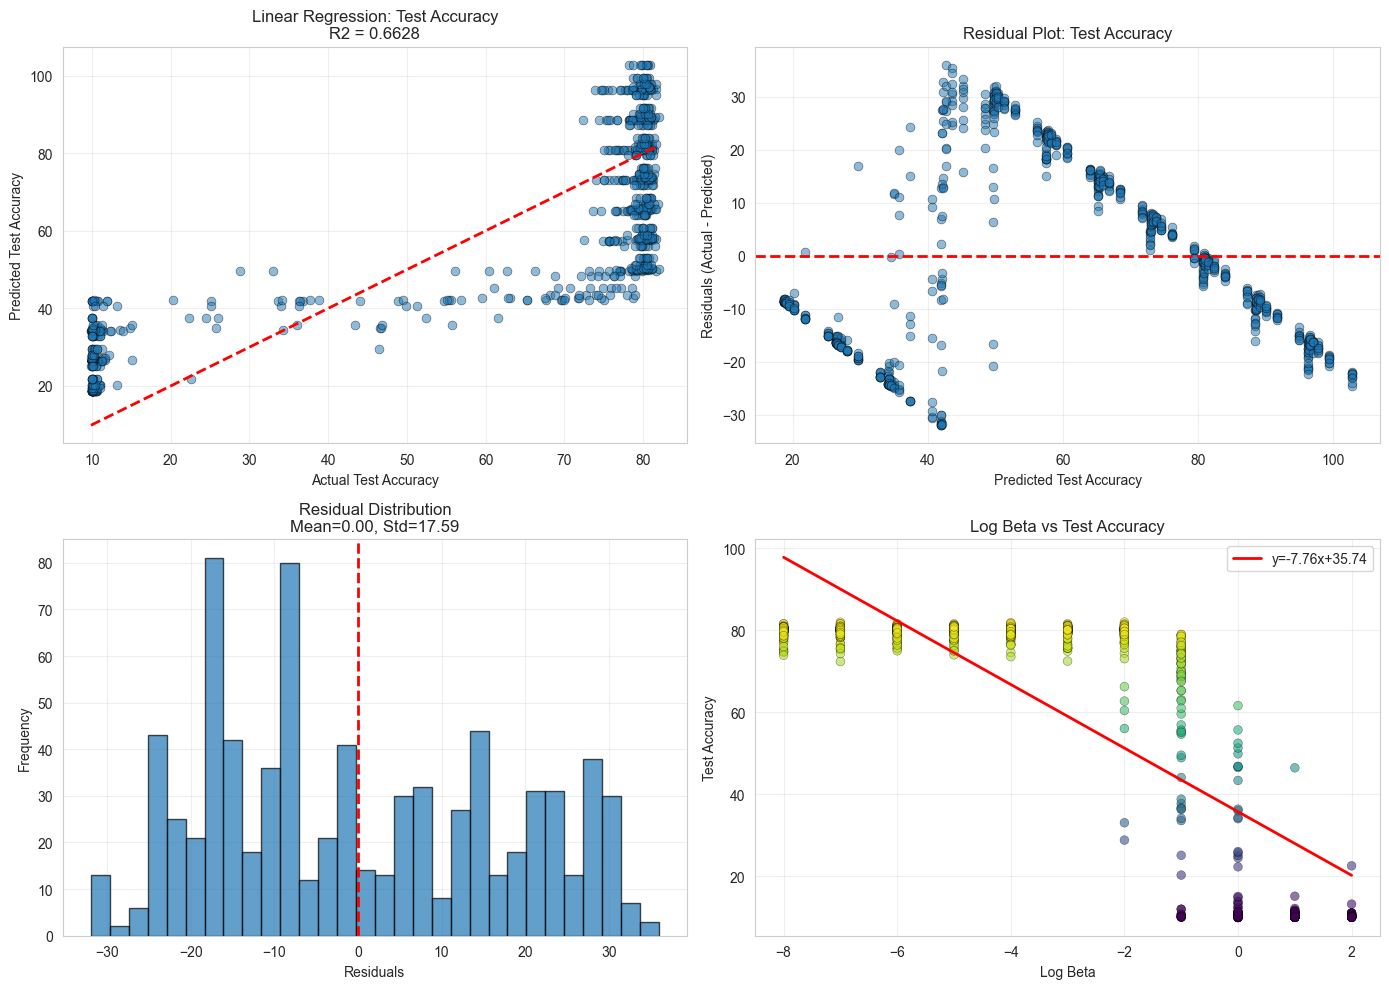

In [11]:
# Visualize regression results with residual analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Actual vs Predicted (Accuracy)
ax = axes[0, 0]
ax.scatter(y_accuracy, y_pred_acc, alpha=0.5, edgecolors='black', linewidth=0.5, s=40)
ax.plot([y_accuracy.min(), y_accuracy.max()], [y_accuracy.min(), y_accuracy.max()], 'r--', lw=2)
ax.set_xlabel('Actual Test Accuracy')
ax.set_ylabel('Predicted Test Accuracy')
ax.set_title(f'Linear Regression: Test Accuracy\nR2 = {r2_score(y_accuracy, y_pred_acc):.4f}')
ax.grid(True, alpha=0.3)

# Top-right: Residuals (Accuracy)
ax = axes[0, 1]
residuals_acc = y_accuracy - y_pred_acc
ax.scatter(y_pred_acc, residuals_acc, alpha=0.5, edgecolors='black', linewidth=0.5, s=40)
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Predicted Test Accuracy')
ax.set_ylabel('Residuals (Actual - Predicted)')
ax.set_title('Residual Plot: Test Accuracy')
ax.grid(True, alpha=0.3)

# Bottom-left: Residual distribution (Accuracy)
ax = axes[1, 0]
ax.hist(residuals_acc, bins=30, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Residuals')
ax.set_ylabel('Frequency')
ax.set_title(
	f'Residual Distribution\nMean={residuals_acc.mean():.2f}, Std={residuals_acc.std():.2f}'
)
ax.grid(True, alpha=0.3)

# Bottom-right: Feature relationship (log_beta vs accuracy)
ax = axes[1, 1]
scatter = ax.scatter(
	df['log_beta'],
	df['test_accuracy'],
	c=df['test_accuracy'],
	cmap=BOTTLENECK_CMAP,
	alpha=0.6,
	s=40,
	edgecolors='black',
	linewidth=0.3,
)
# Add regression line
z = np.polyfit(df['log_beta'], df['test_accuracy'], 1)
p = np.poly1d(z)
ax.plot(
	df['log_beta'].sort_values(),
	p(df['log_beta'].sort_values()),
	'r-',
	lw=2,
	label=f'y={z[0]:.2f}x+{z[1]:.2f}',
)
ax.set_xlabel('Log Beta')
ax.set_ylabel('Test Accuracy')
ax.set_title('Log Beta vs Test Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'regression_predictions.png', dpi=150)
print(f'\nSaved: regression_predictions.png')
plt.show()

In [12]:
# =============================================================================
# SECTION 3: NON-LINEAR MODELS (Random Forest, Gradient Boosting)
# =============================================================================
print('\n' + '=' * 60)
print('SECTION 3: NON-LINEAR MODELS')
print('=' * 60)

# Prepare features with more variables
X_full = df[['log_beta', 'bottleneck_width']].copy()
# Add interaction term
X_full['beta_x_width'] = X_full['log_beta'] * X_full['bottleneck_width']
X_full['width_squared'] = X_full['bottleneck_width'] ** 2

# Model 3: Random Forest for test_accuracy
print('\n--- Random Forest: Test Accuracy ---')
rf_accuracy = RandomForestRegressor(
	n_estimators=100, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1
)
rf_accuracy.fit(X_full, y_accuracy)
y_pred_rf = rf_accuracy.predict(X_full)

print(f'Train R2: {r2_score(y_accuracy, y_pred_rf):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_accuracy, y_pred_rf)):.4f}')

# Feature importance
print('\nFeature Importance (Random Forest):')
for feat, imp in zip(X_full.columns, rf_accuracy.feature_importances_):
	print(f'  {feat}: {imp:.4f}')

# Cross-validation
cv_rf = cross_val_score(rf_accuracy, X_full, y_accuracy, cv=5, scoring='r2')
print(f'\nCross-validation R2: {cv_rf.mean():.4f} (+/- {cv_rf.std() * 2:.4f})')


SECTION 3: NON-LINEAR MODELS

--- Random Forest: Test Accuracy ---
Train R2: 0.9670
RMSE: 5.5024

Feature Importance (Random Forest):
  log_beta: 0.0286
  bottleneck_width: 0.0073
  beta_x_width: 0.9558
  width_squared: 0.0083

Cross-validation R2: 0.9503 (+/- 0.0379)


In [13]:
# Model 4: Gradient Boosting for test_accuracy
print('\n--- Gradient Boosting: Test Accuracy ---')
gb_accuracy = GradientBoostingRegressor(
	n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42
)
gb_accuracy.fit(X_full, y_accuracy)
y_pred_gb = gb_accuracy.predict(X_full)

print(f'Train R2: {r2_score(y_accuracy, y_pred_gb):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_accuracy, y_pred_gb)):.4f}')

print('\nFeature Importance (Gradient Boosting):')
for feat, imp in zip(X_full.columns, gb_accuracy.feature_importances_):
	print(f'  {feat}: {imp:.4f}')

cv_gb = cross_val_score(gb_accuracy, X_full, y_accuracy, cv=5, scoring='r2')
print(f'\nCross-validation R2: {cv_gb.mean():.4f} (+/- {cv_gb.std() * 2:.4f})')


--- Gradient Boosting: Test Accuracy ---
Train R2: 0.9670
RMSE: 5.4978

Feature Importance (Gradient Boosting):
  log_beta: 0.0278
  bottleneck_width: 0.0116
  beta_x_width: 0.9569
  width_squared: 0.0037

Cross-validation R2: 0.9509 (+/- 0.0373)



--- Model Comparison ---
               Model  CV_R2_Mean  CV_R2_Std
0  Linear Regression    0.656450   0.025108
1              Ridge    0.656450   0.025108
2      Random Forest    0.950348   0.018959
3  Gradient Boosting    0.950863   0.018670

Saved: feature_importance.png


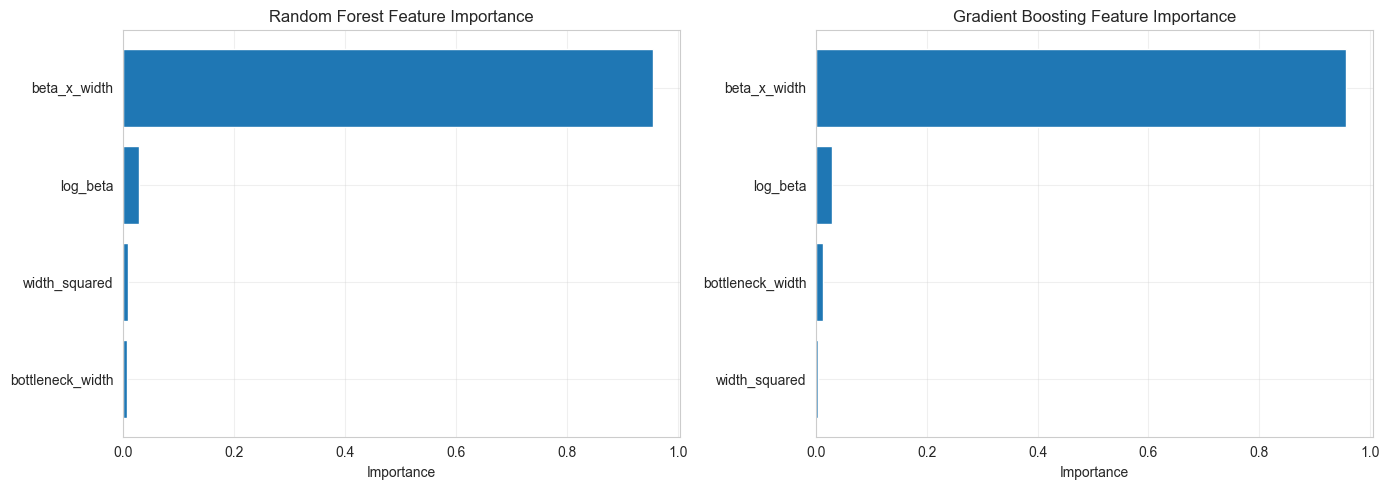

In [14]:
# Compare model performance
print('\n--- Model Comparison ---')
models_comparison = pd.DataFrame(
	{
		'Model': ['Linear Regression', 'Ridge', 'Random Forest', 'Gradient Boosting'],
		'CV_R2_Mean': [cv_scores.mean(), cv_scores.mean(), cv_rf.mean(), cv_gb.mean()],
		'CV_R2_Std': [cv_scores.std(), cv_scores.std(), cv_rf.std(), cv_gb.std()],
	}
)
print(models_comparison)

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
rf_importance = pd.DataFrame(
	{'Feature': X_full.columns, 'Importance': rf_accuracy.feature_importances_}
).sort_values('Importance', ascending=True)
ax.barh(rf_importance['Feature'], rf_importance['Importance'])
ax.set_xlabel('Importance')
ax.set_title('Random Forest Feature Importance')
ax.grid(True, alpha=0.3)

ax = axes[1]
gb_importance = pd.DataFrame(
	{'Feature': X_full.columns, 'Importance': gb_accuracy.feature_importances_}
).sort_values('Importance', ascending=True)
ax.barh(gb_importance['Feature'], gb_importance['Importance'])
ax.set_xlabel('Importance')
ax.set_title('Gradient Boosting Feature Importance')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=150)
print(f'\nSaved: feature_importance.png')
plt.show()


SECTION 4: UNSUPERVISED LEARNING - CLUSTERING

--- K-Means Clustering ---
Saved: elbow_method.png
Best k by silhouette score: 2 (score=0.4812)


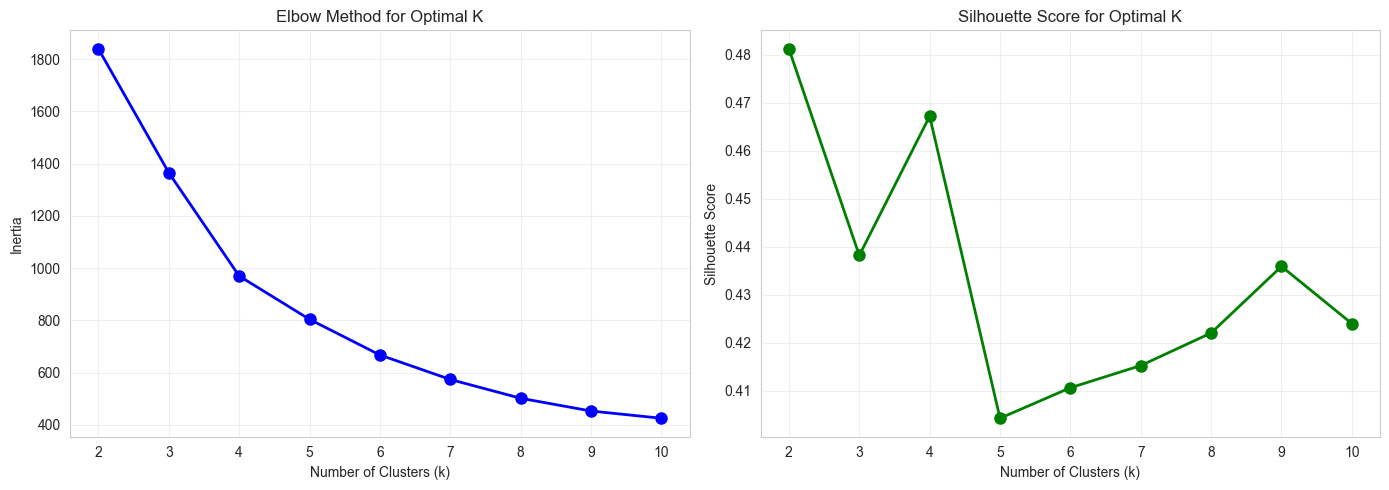

In [15]:
# =============================================================================
# SECTION 4: UNSUPERVISED LEARNING - CLUSTERING
# =============================================================================
print('\n' + '=' * 60)
print('SECTION 4: UNSUPERVISED LEARNING - CLUSTERING')
print('=' * 60)

# Prepare data for clustering
cluster_features = ['log_beta', 'bottleneck_width', 'test_accuracy', 'final_empirical_compression']
X_cluster = df[cluster_features].copy()

# Standardize features
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# K-Means clustering
print('\n--- K-Means Clustering ---')

# Find optimal k using elbow method AND silhouette score
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
k_range = range(2, 11)
for k in k_range:
	kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
	labels = kmeans.fit_predict(X_cluster_scaled)
	inertias.append(kmeans.inertia_)
	silhouette_scores.append(silhouette_score(X_cluster_scaled, labels))

# Plot elbow curve with silhouette score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Optimal K')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score for Optimal K')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'elbow_method.png', dpi=150)
print(f'Saved: elbow_method.png')

# Print best k by silhouette score
best_k_idx = np.argmax(silhouette_scores)
print(
	f'Best k by silhouette score: {list(k_range)[best_k_idx]} (score={silhouette_scores[best_k_idx]:.4f})'
)
plt.show()

In [16]:
# Apply K-Means with optimal k (typically 4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Analyze cluster characteristics
print(f'\n--- Cluster Characteristics (k={optimal_k}) ---')
cluster_stats = df.groupby('cluster')[cluster_features].agg(['mean', 'std'])
print(cluster_stats.round(3))


--- Cluster Characteristics (k=4) ---
        log_beta        bottleneck_width          test_accuracy          \
            mean    std             mean      std          mean     std   
cluster                                                                   
0         -4.746  2.183          175.052  174.986        78.442   4.277   
1          0.370  1.054          321.383  492.745        17.501  14.049   
2          0.969  0.954          498.700  669.283        13.260   9.966   
3         -4.401  2.375         1546.449  513.643        78.471   5.876   

        final_empirical_compression         
                               mean    std  
cluster                                     
0                             8.296  0.098  
1                             8.013  0.301  
2                             8.668  0.140  
3                             8.296  0.123  


Saved: cluster_visualization.png


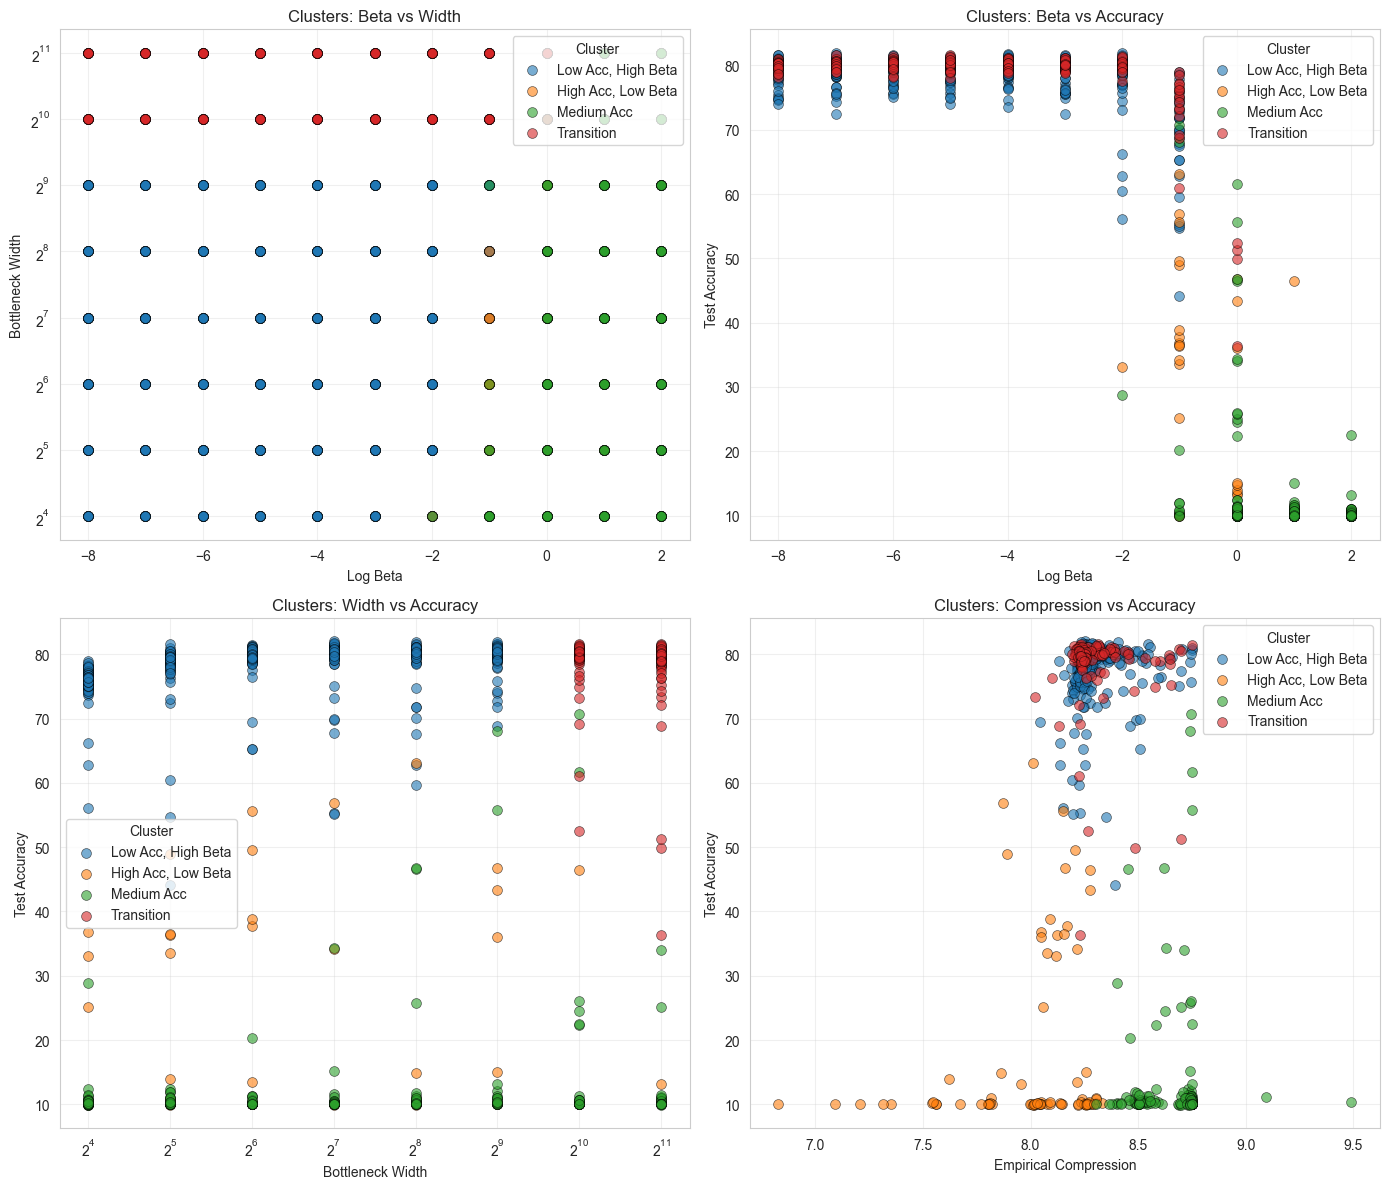

In [17]:
# Visualize clusters - improved with discrete legend
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Create discrete color map for clusters
cluster_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
cluster_labels = ['Low Acc, High Beta', 'High Acc, Low Beta', 'Medium Acc', 'Transition']

# Cluster visualization in different projections
ax = axes[0, 0]
for cluster_id in range(optimal_k):
	cluster_mask = df['cluster'] == cluster_id
	ax.scatter(
		df.loc[cluster_mask, 'log_beta'],
		df.loc[cluster_mask, 'bottleneck_width'],
		c=[cluster_colors[cluster_id]],
		label=cluster_labels[cluster_id],
		alpha=0.6,
		s=50,
		edgecolors='black',
		linewidth=0.5,
	)
ax.set_xlabel('Log Beta')
ax.set_ylabel('Bottleneck Width')
ax.set_title('Clusters: Beta vs Width')
ax.set_yscale('log', base=2)
ax.legend(title='Cluster', loc='best')
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for cluster_id in range(optimal_k):
	cluster_mask = df['cluster'] == cluster_id
	ax.scatter(
		df.loc[cluster_mask, 'log_beta'],
		df.loc[cluster_mask, 'test_accuracy'],
		c=[cluster_colors[cluster_id]],
		label=cluster_labels[cluster_id],
		alpha=0.6,
		s=50,
		edgecolors='black',
		linewidth=0.5,
	)
ax.set_xlabel('Log Beta')
ax.set_ylabel('Test Accuracy')
ax.set_title('Clusters: Beta vs Accuracy')
ax.legend(title='Cluster', loc='best')
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
for cluster_id in range(optimal_k):
	cluster_mask = df['cluster'] == cluster_id
	ax.scatter(
		df.loc[cluster_mask, 'bottleneck_width'],
		df.loc[cluster_mask, 'test_accuracy'],
		c=[cluster_colors[cluster_id]],
		label=cluster_labels[cluster_id],
		alpha=0.6,
		s=50,
		edgecolors='black',
		linewidth=0.5,
	)
ax.set_xlabel('Bottleneck Width')
ax.set_ylabel('Test Accuracy')
ax.set_title('Clusters: Width vs Accuracy')
ax.set_xscale('log', base=2)
ax.legend(title='Cluster', loc='best')
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
for cluster_id in range(optimal_k):
	cluster_mask = df['cluster'] == cluster_id
	ax.scatter(
		df.loc[cluster_mask, 'final_empirical_compression'],
		df.loc[cluster_mask, 'test_accuracy'],
		c=[cluster_colors[cluster_id]],
		label=cluster_labels[cluster_id],
		alpha=0.6,
		s=50,
		edgecolors='black',
		linewidth=0.5,
	)
ax.set_xlabel('Empirical Compression')
ax.set_ylabel('Test Accuracy')
ax.set_title('Clusters: Compression vs Accuracy')
ax.legend(title='Cluster', loc='best')
ax.grid(True, alpha=0.3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cluster_visualization.png', dpi=150)
print(f'Saved: cluster_visualization.png')
plt.show()

In [18]:
# DBSCAN for density-based clustering
print('\n--- DBSCAN Clustering ---')
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_cluster_scaled)

n_clusters_dbscan = len(set(df['dbscan_cluster'])) - (
	1 if -1 in df['dbscan_cluster'].values else 0
)
n_noise = list(df['dbscan_cluster']).count(-1)
print(f'Number of clusters: {n_clusters_dbscan}')
print(f'Number of noise points: {n_noise}')


--- DBSCAN Clustering ---
Number of clusters: 8
Number of noise points: 77


In [19]:
# =============================================================================
# SECTION 5: PRINCIPAL COMPONENT ANALYSIS (PCA)
# =============================================================================
print('\n' + '=' * 60)
print('SECTION 5: PRINCIPAL COMPONENT ANALYSIS')
print('=' * 60)

# PCA on all numerical features
pca_features = [
	'log_beta',
	'bottleneck_width',
	'test_accuracy',
	'final_empirical_compression',
	'final_val_loss',
	'final_effective_capacity_utilization',
]
# Drop rows with NaN or infinite values for PCA
X_pca = df[pca_features].copy()
X_pca = X_pca.replace([np.inf, -np.inf], np.nan)
X_pca = X_pca.dropna()
print(f'\nPCA samples after cleaning: {len(X_pca)} (dropped {len(df) - len(X_pca)} rows)')

X_pca_scaled = scaler.fit_transform(X_pca)

pca = PCA()
X_pca_transformed = pca.fit_transform(X_pca_scaled)

# Explained variance
print('\n--- Explained Variance Ratio ---')
for i, var in enumerate(pca.explained_variance_ratio_):
	print(f'PC{i + 1}: {var:.4f}')

print(f'\nCumulative Explained Variance:')
cumsum = np.cumsum(pca.explained_variance_ratio_)
for i, c in enumerate(cumsum):
	print(f'PC{i + 1}: {c:.4f}')


SECTION 5: PRINCIPAL COMPONENT ANALYSIS

PCA samples after cleaning: 793 (dropped 0 rows)

--- Explained Variance Ratio ---
PC1: 0.6428
PC2: 0.1684
PC3: 0.1436
PC4: 0.0445
PC5: 0.0006
PC6: 0.0001

Cumulative Explained Variance:
PC1: 0.6428
PC2: 0.8112
PC3: 0.9548
PC4: 0.9993
PC5: 0.9999
PC6: 1.0000



--- PCA Loadings ---
                                        PC1    PC2    PC3    PC4    PC5    PC6
log_beta                              0.449  0.067 -0.105  0.885 -0.006  0.000
bottleneck_width                     -0.039  0.963 -0.252 -0.083  0.010 -0.007
test_accuracy                        -0.501  0.025  0.111  0.271  0.809  0.096
final_empirical_compression           0.207  0.255  0.944 -0.012 -0.005  0.000
final_val_loss                        0.502 -0.027 -0.105 -0.263  0.325  0.750
final_effective_capacity_utilization  0.502 -0.038 -0.101 -0.260  0.490 -0.655

Saved: pca_analysis.png


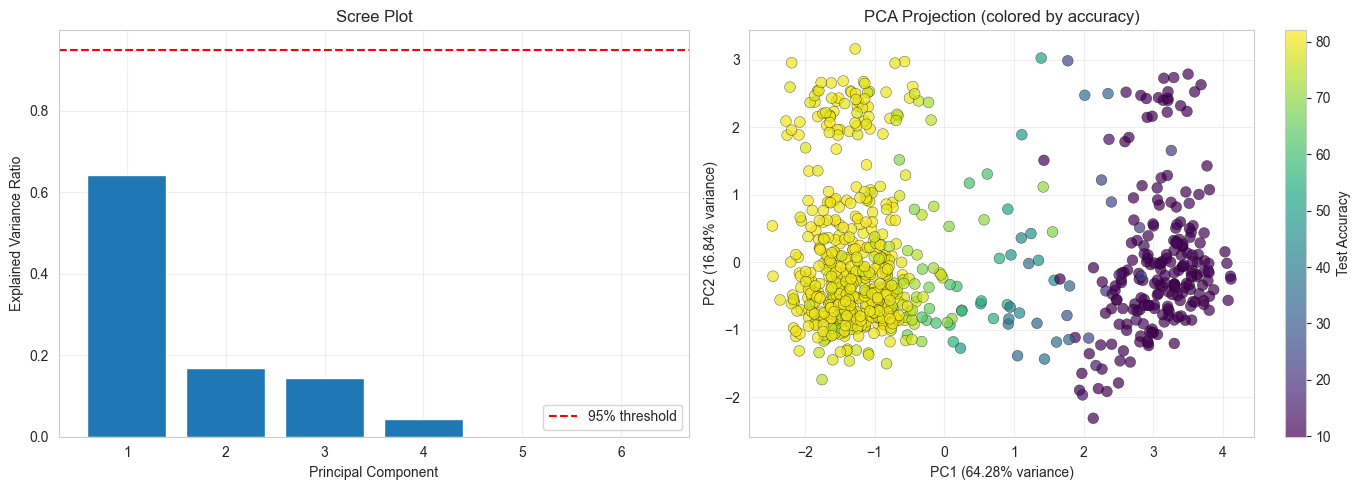

In [20]:
# PCA loadings
print('\n--- PCA Loadings ---')
loadings = pd.DataFrame(
	pca.components_.T,
	columns=[f'PC{i + 1}' for i in range(len(pca.components_))],
	index=pca_features,
)
print(loadings.round(3))

# Visualize PCA - improved
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ax = axes[0]
ax.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Scree Plot')
ax.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax.legend()
ax.grid(True, alpha=0.3)

# PCA projection with better visibility
ax = axes[1]
# Use test_accuracy from cleaned X_pca dataframe (matching the PCA data)
accuracy_colors = X_pca['test_accuracy'].values

# Add jitter for better visibility
np.random.seed(42)
jitter = np.random.normal(0, 0.3, size=X_pca_transformed.shape)
X_pca_jittered = X_pca_transformed + jitter

scatter = ax.scatter(
	X_pca_jittered[:, 0],
	X_pca_jittered[:, 1],
	c=accuracy_colors,
	cmap=BOTTLENECK_CMAP,
	alpha=0.7,
	s=60,
	edgecolors='black',
	linewidth=0.3,
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
ax.set_title('PCA Projection (colored by accuracy)')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Test Accuracy')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pca_analysis.png', dpi=150)
print(f'\nSaved: pca_analysis.png')
plt.show()

In [21]:
# =============================================================================
# SECTION 6: DECISION TREE FOR INTERPRETABILITY
# =============================================================================
print('\n' + '=' * 60)
print('SECTION 6: DECISION TREE FOR INTERPRETABILITY')
print('=' * 60)

# Train a shallow decision tree
dt = DecisionTreeRegressor(max_depth=4, min_samples_split=10, random_state=42)
dt.fit(X_full, y_accuracy)
print(f'Decision Tree R2: {r2_score(y_accuracy, dt.predict(X_full)):.4f}')

# Feature importance from decision tree
print('\nDecision Tree Feature Importance:')
for feat, imp in zip(X_full.columns, dt.feature_importances_):
	print(f'  {feat}: {imp:.4f}')


SECTION 6: DECISION TREE FOR INTERPRETABILITY
Decision Tree R2: 0.9664

Decision Tree Feature Importance:
  log_beta: 0.0290
  bottleneck_width: 0.0001
  beta_x_width: 0.9478
  width_squared: 0.0232



Saved: decision_tree.png


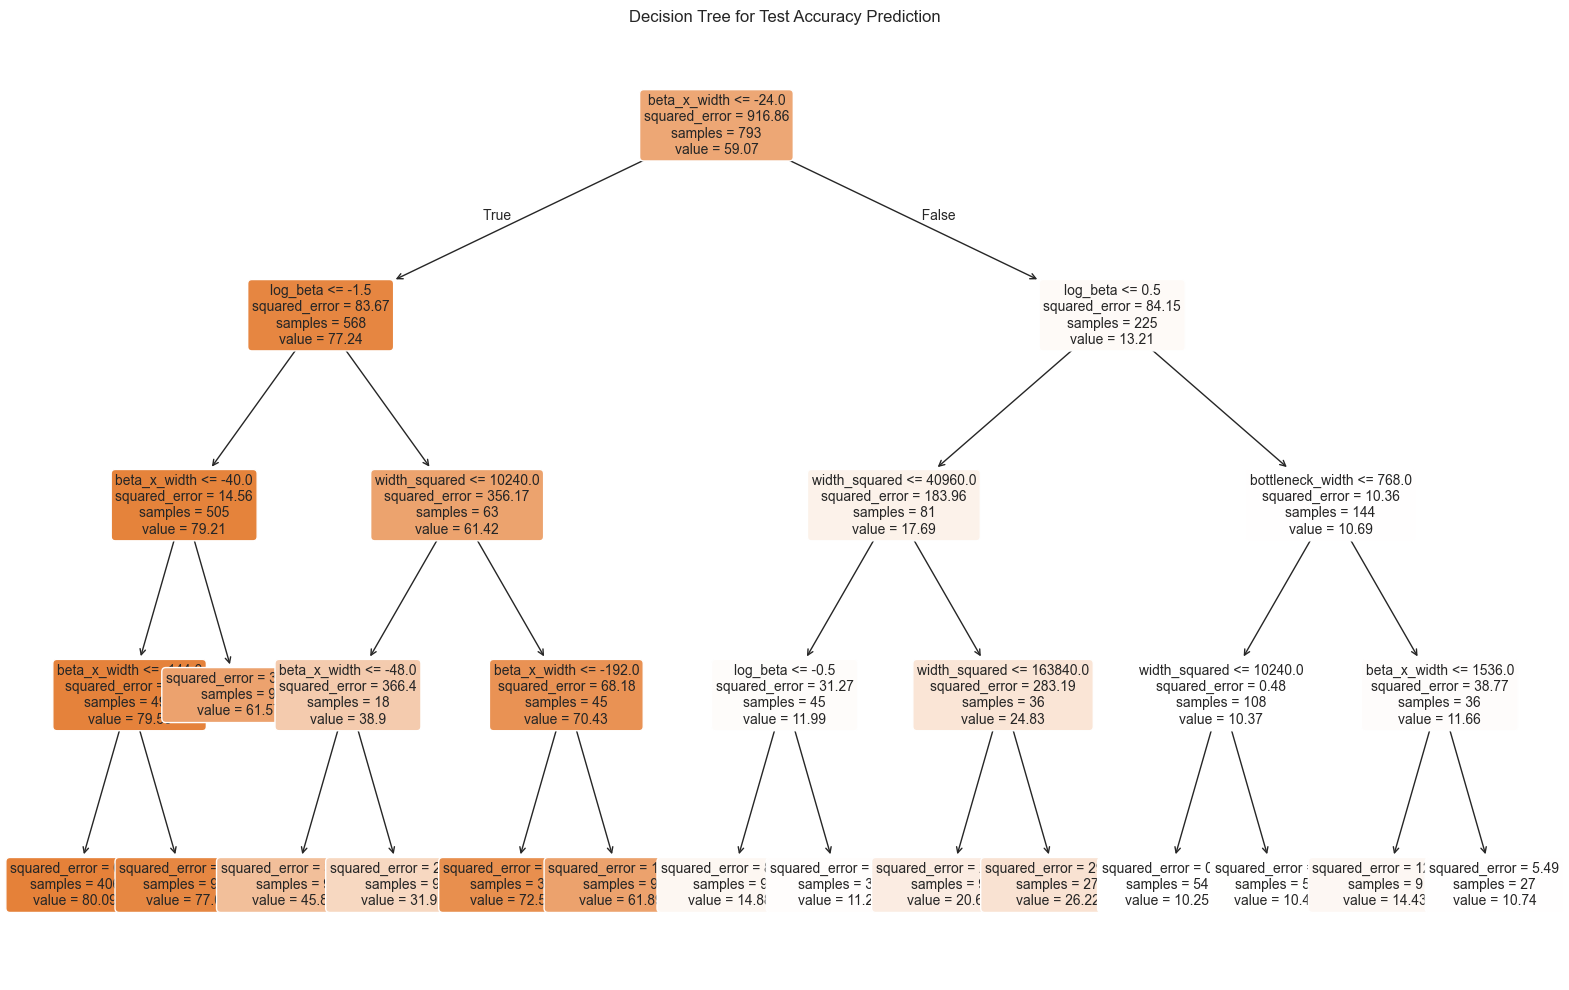

In [22]:
# Visualize decision tree
fig, ax = plt.subplots(figsize=(16, 10))
plot_tree(
	dt,
	feature_names=X_full.columns,
	filled=True,
	rounded=True,
	precision=2,
	ax=ax,
	fontsize=10,
)
ax.set_title('Decision Tree for Test Accuracy Prediction')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'decision_tree.png', dpi=150, bbox_inches='tight')
print(f'\nSaved: decision_tree.png')
plt.show()

In [23]:
# =============================================================================
# SECTION 7: ANALYSIS BY MODEL ARCHITECTURE
# =============================================================================
print('\n' + '=' * 60)
print('SECTION 7: ANALYSIS BY MODEL ARCHITECTURE')
print('=' * 60)

# Encode model architecture
le = LabelEncoder()
df['model_arch_encoded'] = le.fit_transform(df['model_arch'])

# Analyze each architecture separately
for model_arch in df['model_arch'].unique():
	model_df = df[df['model_arch'] == model_arch]

	print(f'\n--- {model_arch} ---')
	print(f'  Samples: {len(model_df)}')

	# Correlations for this architecture
	corr_beta = model_df['log_beta'].corr(model_df['test_accuracy'])
	corr_width = model_df['bottleneck_width'].corr(model_df['test_accuracy'])
	print(f'  Correlation (log_beta, accuracy): {corr_beta:.4f}')
	print(f'  Correlation (width, accuracy): {corr_width:.4f}')

	# Fit simple model
	X_model = model_df[['log_beta', 'bottleneck_width']]
	y_model = model_df['test_accuracy']

	rf_model = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
	rf_model.fit(X_model, y_model)
	cv_model = cross_val_score(rf_model, X_model, y_model, cv=5, scoring='r2')

	print(f'  RF CV R2: {cv_model.mean():.4f} (+/- {cv_model.std() * 2:.4f})')


SECTION 7: ANALYSIS BY MODEL ARCHITECTURE

--- efficientnet_b0 ---
  Samples: 264
  Correlation (log_beta, accuracy): -0.8010
  Correlation (width, accuracy): 0.0786
  RF CV R2: 0.8838 (+/- 0.1530)

--- efficientnet_b1 ---
  Samples: 264
  Correlation (log_beta, accuracy): -0.8173
  Correlation (width, accuracy): 0.0616
  RF CV R2: 0.9533 (+/- 0.0697)

--- efficientnet_b2 ---
  Samples: 265
  Correlation (log_beta, accuracy): -0.8170
  Correlation (width, accuracy): 0.0678
  RF CV R2: 0.9291 (+/- 0.1089)


In [24]:
# =============================================================================
# SECTION 8: OPTIMAL CONFIGURATION ANALYSIS
# =============================================================================
print('\n' + '=' * 60)
print('SECTION 8: OPTIMAL CONFIGURATION ANALYSIS')
print('=' * 60)

# Find top configurations
top_n = 20
top_configs = df.nlargest(top_n, 'test_accuracy')

print(f'\n--- Top {top_n} Configurations by Test Accuracy ---')
print(
	top_configs[
		['model_arch', 'bottleneck_width', 'beta', 'test_accuracy', 'final_empirical_compression']
	].to_string()
)

# Analyze common patterns in top configurations
print('\n--- Patterns in Top Configurations ---')
print(f'Average log_beta: {np.log10(top_configs["beta"]).mean():.4f}')
print(f'Average bottleneck_width: {top_configs["bottleneck_width"].mean():.4f}')
print(f'Average compression: {top_configs["final_empirical_compression"].mean():.4f}')

# Compare with bottom configurations
bottom_configs = df.nsmallest(top_n, 'test_accuracy')
print(f'\n--- Bottom {top_n} Configurations ---')
print(f'Average log_beta: {np.log10(bottom_configs["beta"]).mean():.4f}')
print(f'Average bottleneck_width: {bottom_configs["bottleneck_width"].mean():.4f}')


SECTION 8: OPTIMAL CONFIGURATION ANALYSIS

--- Top 20 Configurations by Test Accuracy ---
          model_arch  bottleneck_width          beta  test_accuracy  final_empirical_compression
117  efficientnet_b0               128  1.000000e-02          81.99                     8.254784
136  efficientnet_b0               256  1.000000e-07          81.97                     8.405631
177  efficientnet_b0               512  1.000000e-04          81.83                     8.235407
643  efficientnet_b2               128  1.000000e-04          81.68                     8.287406
234  efficientnet_b0              2048  1.000000e-07          81.63                     8.312809
172  efficientnet_b0               512  1.000000e-06          81.62                     8.244791
115  efficientnet_b0               128  1.000000e-03          81.58                     8.250038
96   efficientnet_b0               128  1.000000e-08          81.57                     8.251873
52   efficientnet_b0                


Saved: optimal_region.png


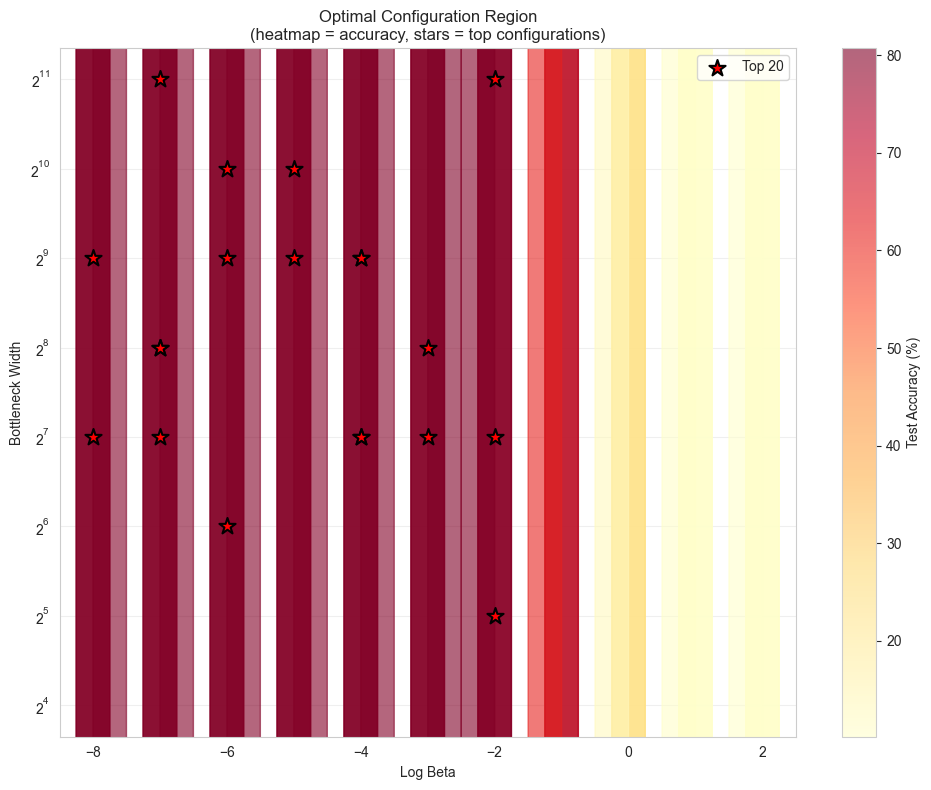

In [25]:
# Visualize optimal region with heatmap background
fig, ax = plt.subplots(figsize=(10, 8))

# Create heatmap background showing accuracy density
from matplotlib.colors import LogNorm

# All points as heatmap
heatmap = ax.hexbin(
	df['log_beta'],
	df['bottleneck_width'],
	C=df['test_accuracy'],
	gridsize=20,
	cmap='YlOrRd',
	mincnt=1,
	alpha=0.6,
)

# Top configurations
ax.scatter(
	np.log10(top_configs['beta']),
	top_configs['bottleneck_width'],
	c='red',
	s=150,
	marker='*',
	edgecolors='black',
	linewidth=1.5,
	label=f'Top {top_n}',
	zorder=5,
)

ax.set_xlabel('Log Beta')
ax.set_ylabel('Bottleneck Width')
ax.set_yscale('log', base=2)
ax.set_title('Optimal Configuration Region\n(heatmap = accuracy, stars = top configurations)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

cb = plt.colorbar(heatmap, ax=ax)
cb.set_label('Test Accuracy (%)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'optimal_region.png', dpi=150)
print(f'\nSaved: optimal_region.png')
plt.show()

In [26]:
# =============================================================================
# SECTION 9: ACCURACY-COMPRESSION TRADE-OFF ANALYSIS
# =============================================================================
print('\n' + '=' * 60)
print('SECTION 9: ACCURACY-COMPRESSION TRADE-OFF')
print('=' * 60)

# Pareto frontier analysis
# Find non-dominated solutions (high accuracy, low compression)
df['pareto_dominated'] = False
for idx, row in df.iterrows():
	# A solution is dominated if another has both higher accuracy and lower compression
	dominated = (
		(df['test_accuracy'] > row['test_accuracy'])
		& (df['final_empirical_compression'] < row['final_empirical_compression'])
	).any()
	df.loc[idx, 'pareto_dominated'] = dominated

pareto_front = df[~df['pareto_dominated']]
print(f'\nPareto-optimal configurations: {len(pareto_front)}')
print(
	pareto_front[
		['model_arch', 'bottleneck_width', 'beta', 'test_accuracy', 'final_empirical_compression']
	]
	.head(10)
	.to_string()
)


SECTION 9: ACCURACY-COMPRESSION TRADE-OFF

Pareto-optimal configurations: 18
          model_arch  bottleneck_width      beta  test_accuracy  final_empirical_compression
26   efficientnet_b0                16  1.000000          10.01                     6.827076
117  efficientnet_b0               128  0.010000          81.99                     8.254784
121  efficientnet_b0               128  0.100000          56.92                     7.873711
156  efficientnet_b0               256  1.000000          10.21                     7.539418
177  efficientnet_b0               512  0.000100          81.83                     8.235407
184  efficientnet_b0               512  0.010000          80.46                     8.179343
187  efficientnet_b0               512  0.100000          78.91                     8.131794
204  efficientnet_b0              1024  0.000001          81.41                     8.231050
222  efficientnet_b0              1024  1.000000          10.07                     7


Saved: pareto_frontier.png


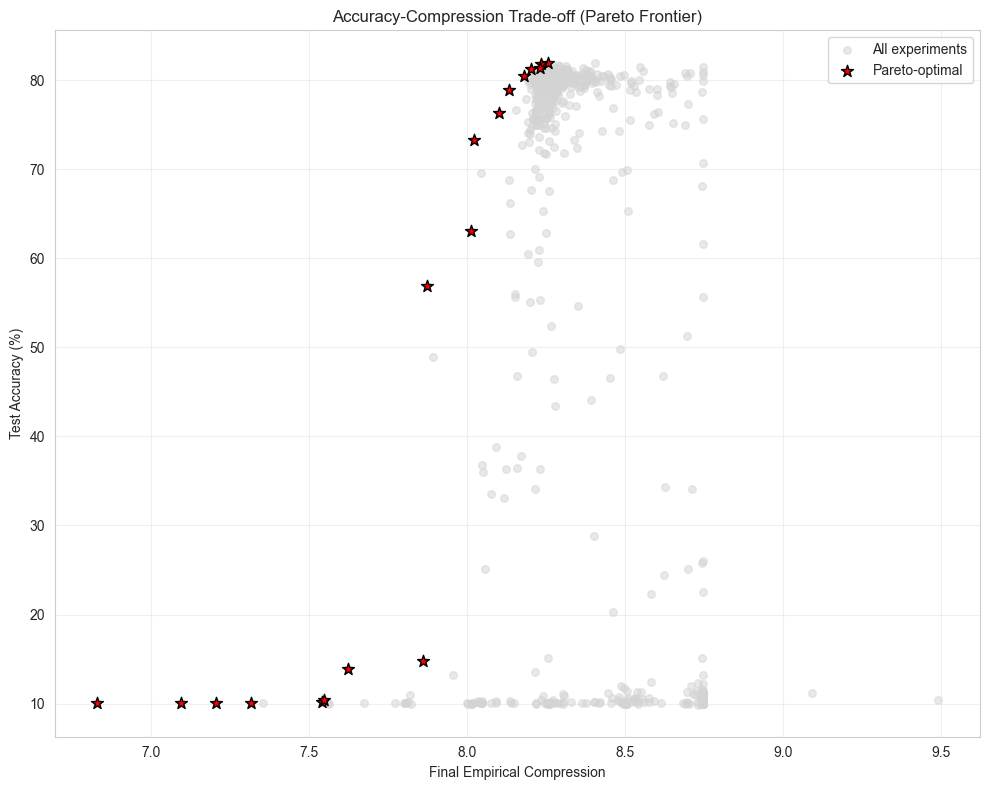

In [27]:
# Visualize Pareto frontier
fig, ax = plt.subplots(figsize=(10, 8))

# All points
ax.scatter(
	df['final_empirical_compression'],
	df['test_accuracy'],
	c='lightgray',
	alpha=0.5,
	s=30,
	label='All experiments',
)

# Pareto front
ax.scatter(
	pareto_front['final_empirical_compression'],
	pareto_front['test_accuracy'],
	c='red',
	s=80,
	marker='*',
	edgecolors='black',
	linewidth=1,
	label='Pareto-optimal',
)

ax.set_xlabel('Final Empirical Compression')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Accuracy-Compression Trade-off (Pareto Frontier)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pareto_frontier.png', dpi=150)
print(f'\nSaved: pareto_frontier.png')
plt.show()

In [28]:
# =============================================================================
# SECTION 10: SUMMARY
# =============================================================================
print('\n' + '=' * 60)
print('SECTION 10: SUMMARY')
print('=' * 60)

# Summary statistics
summary = {
	'Total experiments': len(df),
	'Best accuracy': df['test_accuracy'].max(),
	'Mean accuracy': df['test_accuracy'].mean(),
	'Best compression': df['final_empirical_compression'].min(),
	'Mean compression': df['final_empirical_compression'].mean(),
}

print('\n--- Summary Statistics ---')
for k, v in summary.items():
	print(f'{k}: {v:.4f}' if isinstance(v, float) else f'{k}: {v}')

# Key findings
print('\n--- Key Findings ---')
print(f"""
1. CORRELATION PATTERNS:
   - Log-beta correlation with accuracy: {df['log_beta'].corr(df['test_accuracy']):.4f}
   - Width correlation with accuracy: {df['bottleneck_width'].corr(df['test_accuracy']):.4f}

2. MODEL PERFORMANCE:
   - Linear Regression CV R2: {cv_scores.mean():.4f}
   - Random Forest CV R2: {cv_rf.mean():.4f}
   - Non-linear models improve prediction by: {(cv_rf.mean() - cv_scores.mean()) * 100:.1f}%

3. OPTIMAL CONFIGURATIONS:
   - Average log_beta in top {top_n}: {np.log10(top_configs['beta']).mean():.4f}
   - Average width in top {top_n}: {top_configs['bottleneck_width'].mean():.1f}

4. PARETO-OPTIMAL SOLUTIONS: {len(pareto_front)} configurations found

5. CLUSTER STRUCTURE: {optimal_k} distinct regimes identified
""")


SECTION 10: SUMMARY

--- Summary Statistics ---
Total experiments: 793
Best accuracy: 81.9900
Mean accuracy: 59.0714
Best compression: 6.8271
Mean compression: 8.3421

--- Key Findings ---

1. CORRELATION PATTERNS:
   - Log-beta correlation with accuracy: -0.8111
   - Width correlation with accuracy: 0.0692

2. MODEL PERFORMANCE:
   - Linear Regression CV R2: 0.6564
   - Random Forest CV R2: 0.9503
   - Non-linear models improve prediction by: 29.4%

3. OPTIMAL CONFIGURATIONS:
   - Average log_beta in top 20: -5.0000
   - Average width in top 20: 516.8

4. PARETO-OPTIMAL SOLUTIONS: 18 configurations found

5. CLUSTER STRUCTURE: 4 distinct regimes identified



In [29]:
# Save summary report
report_path = OUTPUT_DIR / 'analysis_summary.txt'
with open(report_path, 'w', encoding='utf-8') as f:
	f.write('Numerical Analysis Summary\n')
	f.write('=' * 60 + '\n\n')
	f.write(f'Total experiments: {len(df)}\n')
	f.write(f'Best accuracy: {df["test_accuracy"].max():.4f}\n')
	f.write(f'Mean accuracy: {df["test_accuracy"].mean():.4f}\n')
	f.write(f'Correlation (log_beta, accuracy): {df["log_beta"].corr(df["test_accuracy"]):.4f}\n')
	f.write(
		f'Correlation (width, accuracy): {df["bottleneck_width"].corr(df["test_accuracy"]):.4f}\n'
	)
	f.write(f'\nModel Performance:\n')
	f.write(f'  Linear Regression CV R2: {cv_scores.mean():.4f}\n')
	f.write(f'  Random Forest CV R2: {cv_rf.mean():.4f}\n')
	f.write(f'\nPareto-optimal configurations: {len(pareto_front)}\n')
	f.write(
		f'Best k for clustering (silhouette): {list(k_range)[best_k_idx]} (score={silhouette_scores[best_k_idx]:.4f})\n'
	)
	f.write(f'\nTop configuration:\n')
	best = df.loc[df['test_accuracy'].idxmax()]
	f.write(f'  Model: {best["model_arch"]}\n')
	f.write(f'  Beta: {best["beta"]}\n')
	f.write(f'  Width: {best["bottleneck_width"]}\n')
	f.write(f'  Accuracy: {best["test_accuracy"]:.4f}\n')

print(f'\nSaved: analysis_summary.txt')
print(f'\nAnalysis complete! Results saved to: {OUTPUT_DIR}')


Saved: analysis_summary.txt

Analysis complete! Results saved to: C:\Users\Michael\Documents\projects\DDIB-Toolkit\reports\efficientnet\numerical_analysis
